Questo codice racchiude i seguenti esperimenti:


*   Train 75ped2+25synth random - test ped2
*   Train 75ped2+25synth random - test MED



Rispetto al training precedente 75/25, qui i video sintetici sono presi in modo randomico.

In [ ]:
import os
from pathlib import Path
import shutil
import re
import time
import natsort
import random

import cv2
from PIL import Image

import numpy as np
from scipy.io import savemat, loadmat
import scipy.io as sio
import pandas as pd

import torch

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns


#1-🛠️Clonazione github e connessione a drive per reperire i frames

In [ ]:
%cd /content
!rm -rf astnet #Pulizia
!git clone https://github.com/marco-caruso/astnet.git
%cd astnet

/content
Cloning into 'astnet'...
remote: Enumerating objects: 939, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 939 (delta 119), reused 57 (delta 57), pack-reused 798 (from 2)
Receiving objects: 100% (939/939), 45.19 MiB | 4.93 MiB/s, done.
Resolving deltas: 100% (552/552), done.
/content/astnet


In [ ]:
# Installazione requirements dalla root come richiesto dal README astnet
!pip install -r requirements.txt

ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.21.5 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

SOURCE_DIR = '/content/drive/MyDrive/datasets/Synth/frames/normal'
DEST_DIR = '/content/drive/MyDrive/datasets/ped2_synth_random/training/frames'
NUM_VIDEOS = 11
RANDOM_SEED = 42


os.makedirs(DEST_DIR, exist_ok=True)


all_videos = [d for d in os.listdir(SOURCE_DIR)
              if os.path.isdir(os.path.join(SOURCE_DIR, d))]

if not all_videos:
    raise ValueError(f"No videos found in {SOURCE_DIR}")

if len(all_videos) < NUM_VIDEOS:
    print(f"⚠️  Only {len(all_videos)} videos available (requested {NUM_VIDEOS})")
    NUM_VIDEOS = len(all_videos)

print(f"📁 Found {len(all_videos)} total videos")

# Select random videos
random.seed(RANDOM_SEED)
selected_videos = random.sample(all_videos, NUM_VIDEOS)

print(f"\n🎲 Random seed: {RANDOM_SEED}")
print(f"✅ Selected {NUM_VIDEOS} videos:")
for i, video in enumerate(sorted(selected_videos), 1):
    print(f"  {i:2d}. {video}")


print(f"\n📋 Copying to {DEST_DIR}...")
copied = 0
for i, video in enumerate(selected_videos, 1):
    src_path = os.path.join(SOURCE_DIR, video)
    dst_path = os.path.join(DEST_DIR, video)

    if os.path.exists(dst_path):
        print(f"  [{i}/{NUM_VIDEOS}] {video} - already exists, skipping")
        continue

    print(f"  [{i}/{NUM_VIDEOS}] {video}...", end='', flush=True)
    shutil.copytree(src_path, dst_path)
    copied += 1
    print(" ✓")


final_count = len(os.listdir(DEST_DIR))
print(f"\n🎉 Done!")
print(f"✅ Copied {copied} new videos")
print(f"✅ Total videos in destination: {final_count}")
print(f"📂 Location: {DEST_DIR}")

📁 Found 142 total videos

🎲 Random seed: 42
✅ Selected 4 videos:
   1. n_0007
   2. n_0029
   3. n_0063
   4. n_0071

📋 Copying to /content/drive/MyDrive/datasets/ped2_synth_2_random/training/frames...
  [1/4] n_0029... ✓
  [2/4] n_0007... ✓
  [3/4] n_0071... ✓
  [4/4] n_0063... ✓

🎉 Done!
✅ Copied 4 new videos
✅ Total videos in destination: 4
📂 Location: /content/drive/MyDrive/datasets/ped2_synth_2_random/training/frames


#2-🔗Creazione dei symlink/Copia dei file da drive

##2.1-Ped2

In [ ]:
#!mkdir -p "/content/astnet/data/ped2/training"
!mkdir -p "/content/astnet/data/ped2/testing"

In [ ]:
print("Inizio copia dei frame:")
!cp -r "/content/drive/MyDrive/datasets/ped2/testing/frames" "/content/astnet/data/ped2/testing/frames"

print("Copia del file ground truth...")
!cp "/content/drive/MyDrive/datasets/ped2/ped2.mat" "/content/astnet/data/ped2/ped2.mat"

print("Finito")

Inizio copia dei frame:
Copia del file ground truth...
Finito


In [ ]:
!ls /content/astnet/data/ped2
#!ls /content/astnet/data/ped2/training/frames
!ls /content/astnet/data/ped2/testing/frames

ped2.mat  testing
01  02	03  04	05  06	07  08	09  10	11  12


In [ ]:
paths_to_fix = [
    '/content/astnet/data/ped2/testing/frames/'
]

def rename_local_frames(base_path):
    if not os.path.exists(base_path):
        print(f"Percorso non trovato: {base_path}")
        return

    subdirs = natsort.natsorted(os.listdir(base_path))
    for subdir in subdirs:
        subdir_path = os.path.join(base_path, subdir)
        if not os.path.isdir(subdir_path): continue

        files = natsort.natsorted([f for f in os.listdir(subdir_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        if not files: continue

        # Controlla se il primo è 000
        if "000" in files[0]:
            print(f"Rinomino: {subdir}")
            for file_name in reversed(files):
                old_path = os.path.join(subdir_path, file_name)
                name_part, ext_part = os.path.splitext(file_name)
                try:
                    new_num = int(name_part) + 1
                    new_name = f"{new_num:03d}{ext_part.lower()}"
                    os.rename(old_path, os.path.join(subdir_path, new_name))
                except ValueError: continue
        else:
            print(f"Salta: {subdir} (già corretto)")

for p in paths_to_fix:
    rename_local_frames(p)
print("Rinomina completata in locale!")

Rinomino: 01
Rinomino: 02
Rinomino: 03
Rinomino: 04
Rinomino: 05
Rinomino: 06
Rinomino: 07
Rinomino: 08
Rinomino: 09
Rinomino: 10
Rinomino: 11
Rinomino: 12
Rinomina completata in locale!


##2.2-Synth+ped2

Copiamo i frame di training di ped2+sintetici. In totale risultano 16 video di ped2 e 4 video del dataset sintetico presi in modo random, per avere un bilanciamento 75/25

In [ ]:
#!mkdir -p "/content/astnet/data/synth/training"
!mkdir -p "/content/astnet/data/ped2_synth_2_random/training"

In [ ]:

print("Inizio copia dei frame di training:")
!cp -r "/content/drive/MyDrive/datasets/ped2_synth_2_random/training/frames" \
      "/content/astnet/data/ped2_synth_2_random/training/frames/"
print("Fine copia dei frame di training.")


print("Finito")

Inizio copia dei frame di training:
Fine copia dei frame di training.
Finito


In [ ]:
!ls /content/astnet/data/ped2_synth_2_random
!ls /content/astnet/data/ped2_synth_2_random/training/frames

training
01  03	05  07	09  11	13  15	n_0007	n_0063
02  04	06  08	10  12	14  16	n_0029	n_0071


Rinominiamo i frames di ped2 per farli partire da 001 invece che da 000

In [ ]:
paths_to_fix = [
    '/content/astnet/data/ped2_synth_2_random/training/frames/'
]

def rename_local_frames(base_path):
    if not os.path.exists(base_path):
        print(f"Percorso non trovato: {base_path}")
        return

    subdirs = natsort.natsorted(os.listdir(base_path))
    for subdir in subdirs:
        subdir_path = os.path.join(base_path, subdir)
        if not os.path.isdir(subdir_path): continue

        files = natsort.natsorted([f for f in os.listdir(subdir_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        if not files: continue

        # Controlla se il primo è 000
        if "000" in files[0]:
            print(f"Rinomino: {subdir}")
            for file_name in reversed(files):
                old_path = os.path.join(subdir_path, file_name)
                name_part, ext_part = os.path.splitext(file_name)
                try:
                    new_num = int(name_part) + 1
                    new_name = f"{new_num:03d}{ext_part.lower()}"
                    os.rename(old_path, os.path.join(subdir_path, new_name))
                except ValueError: continue
        else:
            print(f"Salta: {subdir} (già corretto)")

for p in paths_to_fix:
    rename_local_frames(p)
print("Rinomina completata in locale!")

Rinomino: 01
Rinomino: 02
Rinomino: 03
Rinomino: 04
Rinomino: 05
Rinomino: 06
Rinomino: 07
Rinomino: 08
Rinomino: 09
Rinomino: 10
Rinomino: 11
Rinomino: 12
Rinomino: 13
Rinomino: 14
Rinomino: 15
Rinomino: 16
Salta: n_0007 (già corretto)
Salta: n_0029 (già corretto)
Salta: n_0063 (già corretto)
Salta: n_0071 (già corretto)
Rinomina completata in locale!


##2.3-MED

Per questo dataset, invece di creare collegamenti simbolici (symlink), si è scelto di effettuare una copia fisica dei frame direttamente su Colab.
Questa scelta è motivata dal fatto che l'elevato numero di file coinvolti rende l'uso dei symlink inefficiente, causando rallentamenti significativi durante l'accesso ai dati e le operazioni di testing.

In [ ]:
!mkdir -p "/content/astnet/data/med/testing"

In [ ]:
print("Inizio copia dei frame:")
!cp -r "/content/drive/MyDrive/datasets/med/testing/frames" "/content/astnet/data/med/testing/frames"

print("Copia del file ground truth...")
!cp "/content/drive/MyDrive/datasets/med/med.mat" "/content/astnet/data/med/med.mat"

print("Finito")

Inizio copia dei frame:
Copia del file ground truth...
Finito


In [ ]:
!ls /content/astnet/data/med
!ls /content/astnet/data/med/testing/frames

med.mat  testing
med_0001  med_0005  med_0009  med_0013	med_0017  med_0021  med_0025  med_0029
med_0002  med_0006  med_0010  med_0014	med_0018  med_0022  med_0026  med_0030
med_0003  med_0007  med_0011  med_0015	med_0019  med_0023  med_0027  med_0031
med_0004  med_0008  med_0012  med_0016	med_0020  med_0024  med_0028


#3-⚙️Training

Il training verrà fatto con il dataset ibrido: 75% ped2 e 25% synth. Risultano 16 video del dataset ped2 (2550 frames) e 4 video del dataset sintetico (972 frames) per un totale di 3522 frames.

##3.1-Ped2+synth

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

/content/astnet/ASTNet


In [ ]:
!pip install yacs

In [ ]:
# Crea la cartella
!mkdir -p /content/astnet/ASTNet/datasets/seg_weights/

# Copia il file da Drive
!cp /content/drive/MyDrive/datasets/weights/wider_resnet38.pth /content/astnet/ASTNet/datasets/seg_weights/

In [ ]:
#Modificare nel file .yaml: '/content/astnet/ASTNet/datasets/seg_weights/wider_resnet38.pth'

Copiamo l'ultimo checkpoint da cui ripartire, se serve

In [ ]:
!mkdir -p /content/astnet/ASTNet/output/ped2_synth_2_random/ped2_synth_2_random_wresnet/
!cp /content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth_2_random/epoch_40.pth /content/astnet/ASTNet/output/ped2_synth_2_random/ped2_synth_2_random_wresnet/epoch_40.pth

In [ ]:
!python /content/astnet/ASTNet/train.py --cfg /content/astnet/ASTNet/config/ped2_synth_2_random_wresnet.yaml

=> creating output
=> creating output/ped2_synth_2_random/ped2_synth_2_random_wresnet
=> creating log/ped2_synth_2_random/wrn38/ped2_synth_2_random_wresnet_2026-02-25-21-36
Namespace(cfg='/content/astnet/ASTNet/config/ped2_synth_2_random_wresnet.yaml', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 20, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'ped2_synth_2_random', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 40, 'RESUME': False, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [50, 65], 'LR_FACTOR':

Copia un epoca specifica su drive

In [ ]:
!cp '/content/astnet/ASTNet/output/ped2_synth_2_random/ped2_synth_2_random_wresnet/epoch_40.pth' '/content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth_2_random'

###Recap del training e copia del file .pth in locale per il testing

Epoca 40 con learning rate di 0.0002

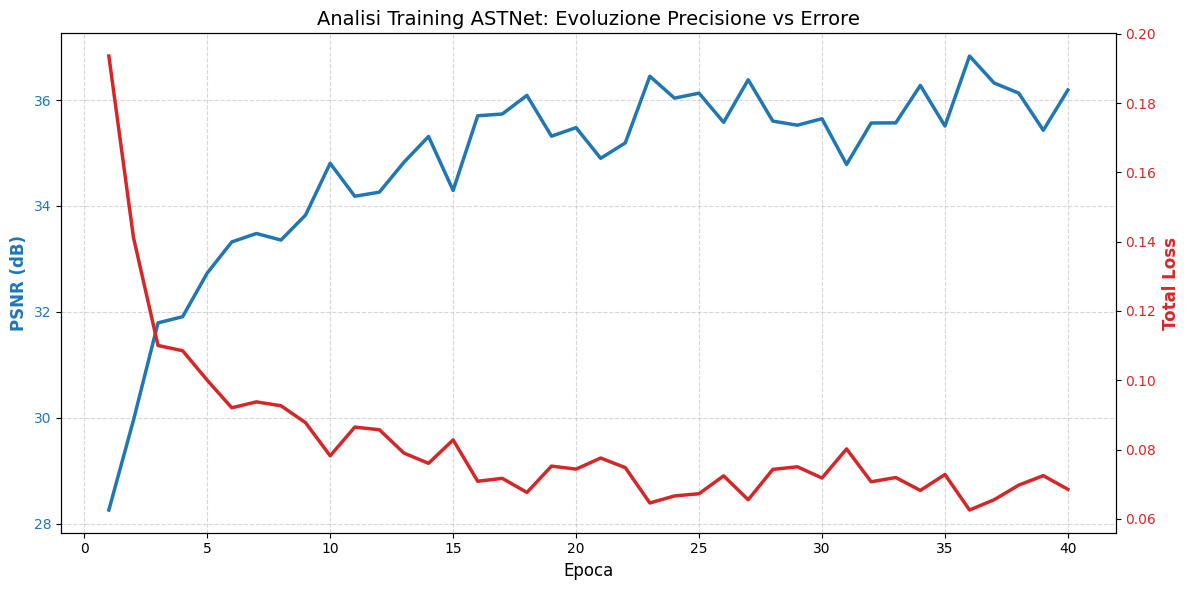

In [ ]:

log_files = [
    "/content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth_2_random/ped2_synth_2_random_wresnet_2026-02-25-21-36_train.log"
]

def plot_training_results(files):
    data = []
    # Pattern per catturare Epoca, le 4 componenti della Loss e il PSNR
    pattern = re.compile(r"Epoch: \[(\d+)\]\[\d+/\d+\].*?inte ([\d\.]+) \+ grad ([\d\.]+) \+ msssim ([\d\.]+) \+ L2 ([\d\.]+)\].*?PSNR ([\d\.]+)")

    for f_path in files:
        with open(f_path, 'r') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    epoch = int(match.group(1))
                    # Loss Totale = somma delle 4 componenti
                    total_loss = float(match.group(2)) + float(match.group(3)) + \
                                 float(match.group(4)) + float(match.group(5))
                    psnr = float(match.group(6))
                    data.append({'Epoch': epoch, 'Loss': total_loss, 'PSNR': psnr})

    if not data:
        print("Nessun dato trovato. Controlla i percorsi dei file.")
        return

    # Tabella e calcolo media per epoca
    df = pd.DataFrame(data).groupby('Epoch').mean().reset_index()

    # Grafico
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Blu: PSNR (asse sinistro)
    ax1.set_xlabel('Epoca', fontsize=12)
    ax1.set_ylabel('PSNR (dB)', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.plot(df['Epoch'], df['PSNR'], color='tab:blue', label='PSNR (Qualità)', linewidth=2.5)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Rosso: Total Loss (asse destro)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Total Loss', color='tab:red', fontsize=12, fontweight='bold')
    ax2.plot(df['Epoch'], df['Loss'], color='tab:red', label='Loss (Errore)', linewidth=2.5)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    plt.title('Analisi Training ASTNet: Evoluzione Precisione vs Errore', fontsize=14)
    fig.tight_layout()
    plt.show()


plot_training_results(log_files)

###Copia in locale del modello trainato

In [ ]:
!cp /content/drive/MyDrive/datasets/Training_Backup/training_ped2_synth_2_random/epoch_40.pth /content/astnet/ASTNet/epoch_40.pth

print("File copiato con successo!")

File copiato con successo!


#4-📝Testing

Operazioni preliminari per evitare errori di tipo

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

/content/astnet/ASTNet


In [ ]:
!pip install yacs

UTILIZZIAMO FRAME_STEPS=2

##4.1-Test ped2

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/ped2_wresnet.yaml \
  --model-file output/ped2_synth_2_random/ped2_synth_2_random_wresnet/epoch_40.pth

/content/astnet/ASTNet
=> creating output/ped2/ped2_wresnet
=> creating log/ped2/wrn38/ped2_wresnet_2026-02-27-10-08
Namespace(cfg='config/ped2_wresnet.yaml', model_file='output/ped2_synth_2_random/ped2_synth_2_random_wresnet/epoch_40.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 2, 'PRINT_FREQ': 20, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/drive/MyDrive/datasets', 'DATASET': 'ped2', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 100}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 40, 'RESUME': False, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [50, 65], 'LR_FACTOR': 0.5}), 'TEST':

Salvataggio del test su drive

In [ ]:
!cp -r /content/astnet/ASTNet/output/ped2 /content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random

##4.3-Test MED

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/med_wresnet.yaml \
  --model-file output/ped2_synth_2_random/ped2_synth_2_random_wresnet/epoch_40.pth

/content/astnet/ASTNet
=> creating output/med/med_wresnet
=> creating log/med/wrn38/med_wresnet_2026-03-02-15-10
Namespace(cfg='config/med_wresnet.yaml', model_file='output/ped2_synth_2_random/ped2_synth_2_random_wresnet/epoch_40.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 0, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'med', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_S

In [ ]:
!cp -r /content/astnet/ASTNet/output/med /content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/secondo_esperimento_med

#5-📈Results

##5.1 Ped2

###Plot

Soglia globale ottimale (Youden) per Ped2: 0.2642
Numero totale di video trovati: 12


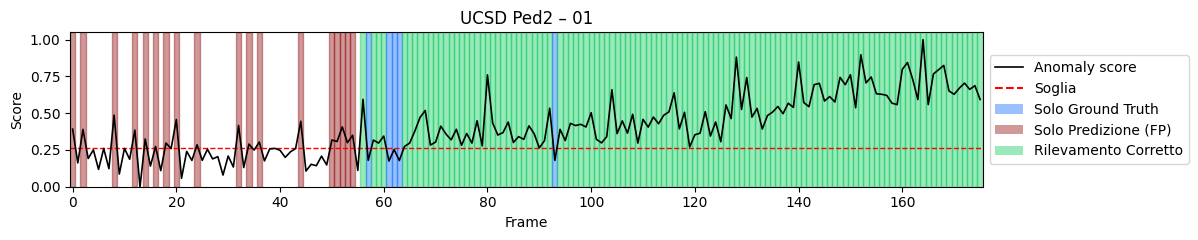

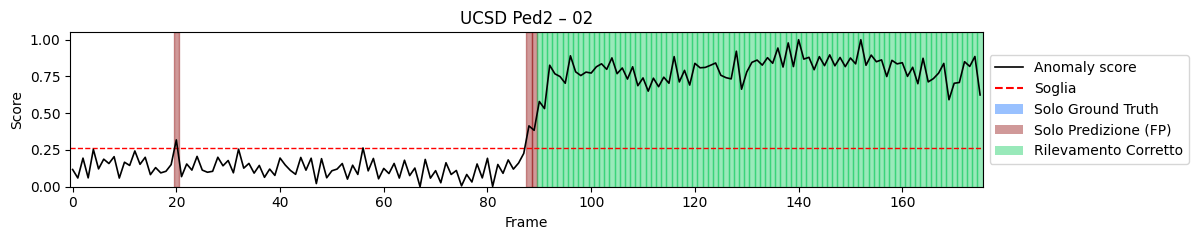

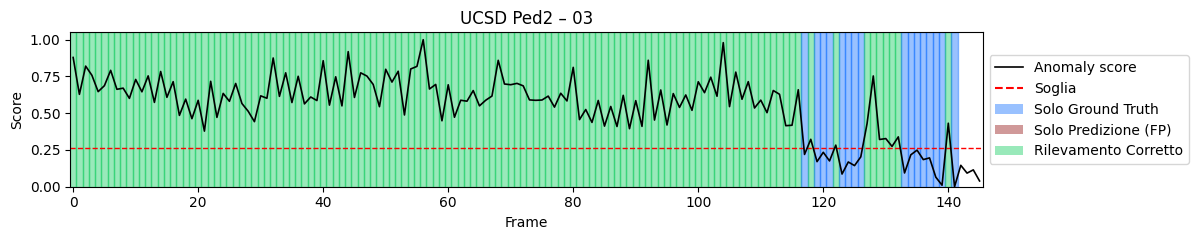

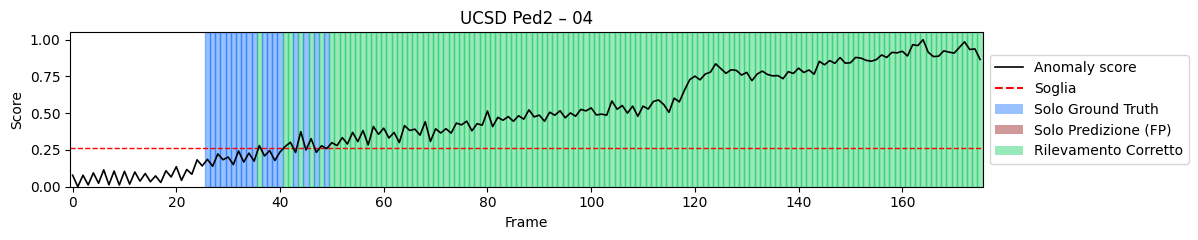

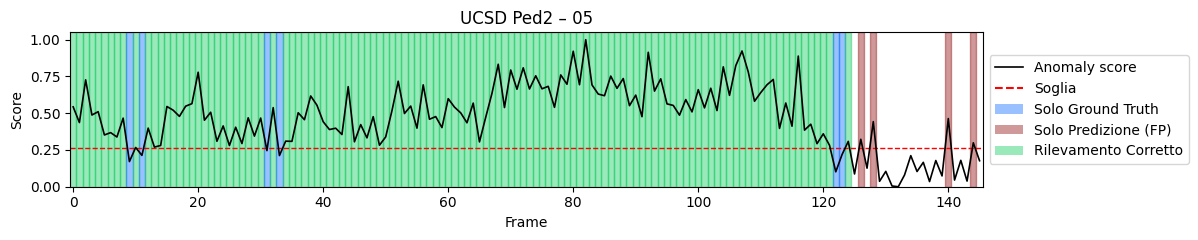

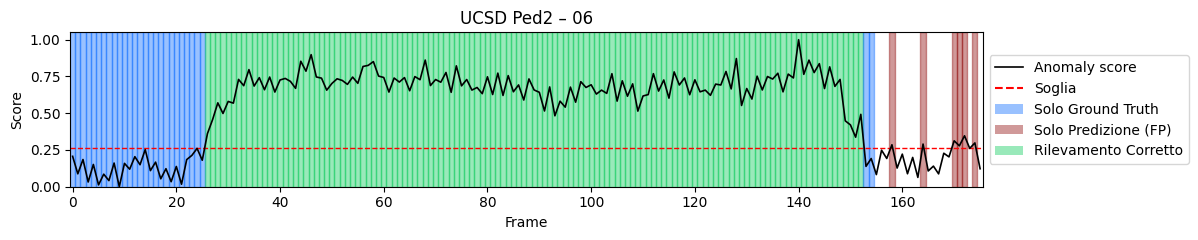

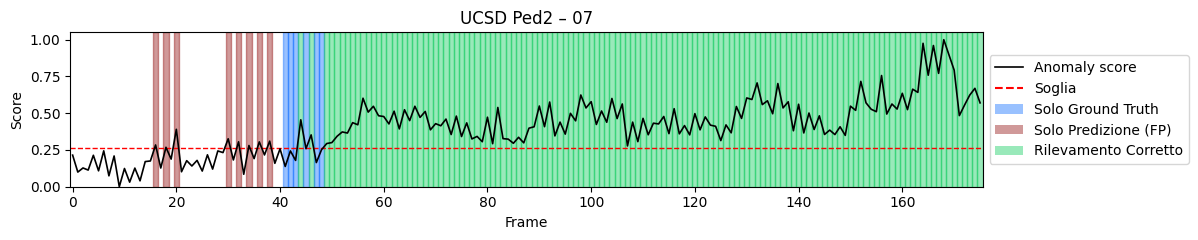

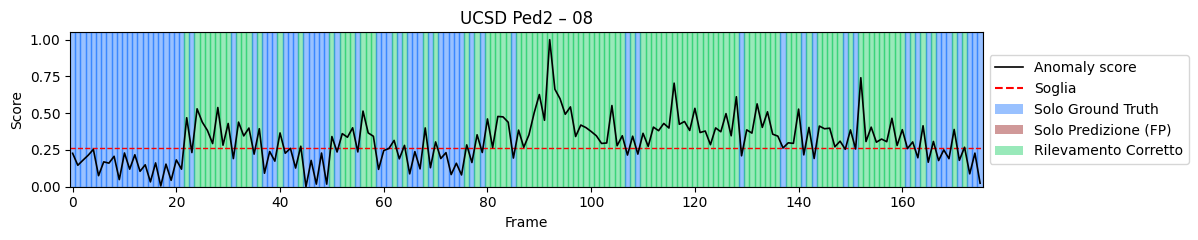

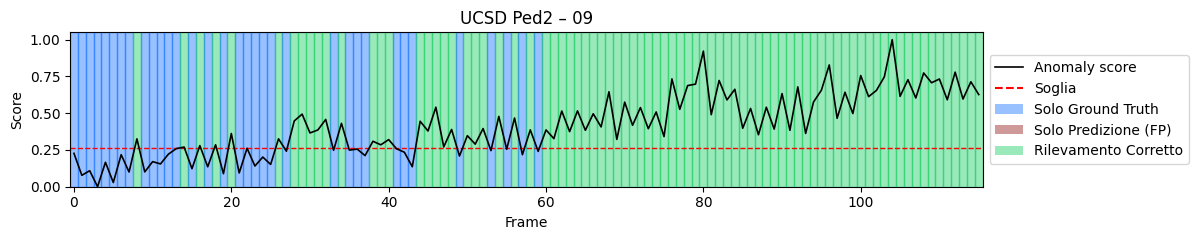

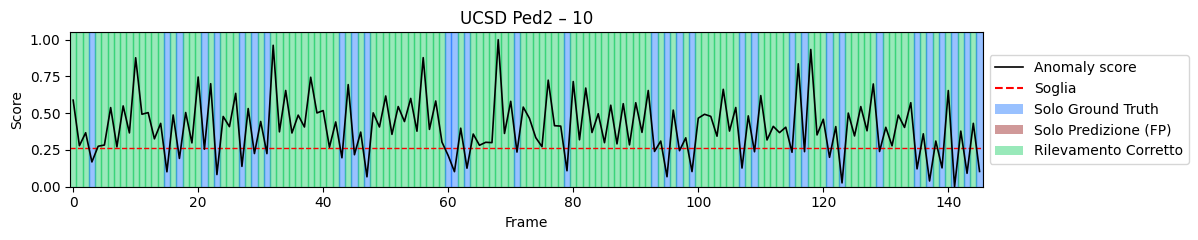

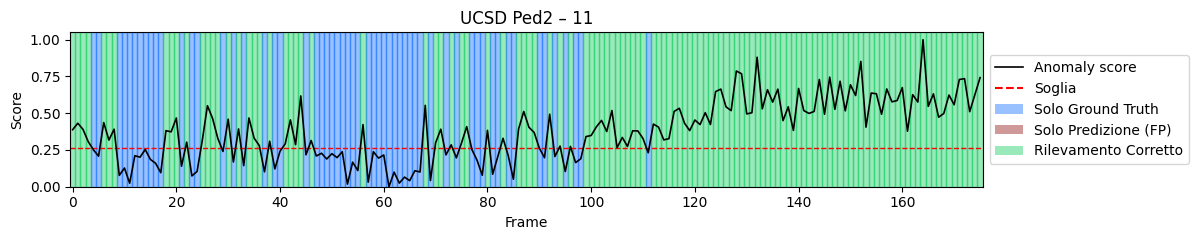

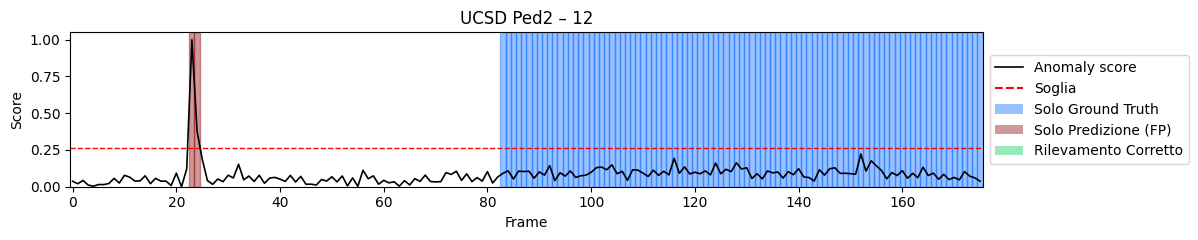

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/ped2/ped2_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/ped2/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per Ped2: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"UCSD Ped2 – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

###ROC CURVE

N video psnr: 12
N video gt: 12
AUC complessiva (PED2): 88.7%


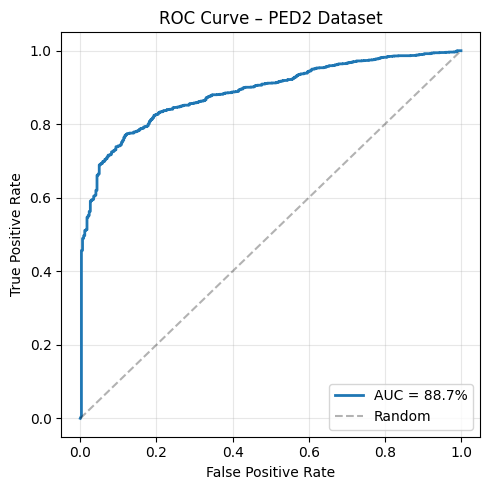

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (PED2): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – PED2 Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.2642

=== METRICHE PED2 ===
Accuracy:  79.10%
Precision: 96.83%
Recall:    77.22%
F1-Score:  85.92%

Matrice di Confusione:
[[ 301   41]
 [ 369 1251]]


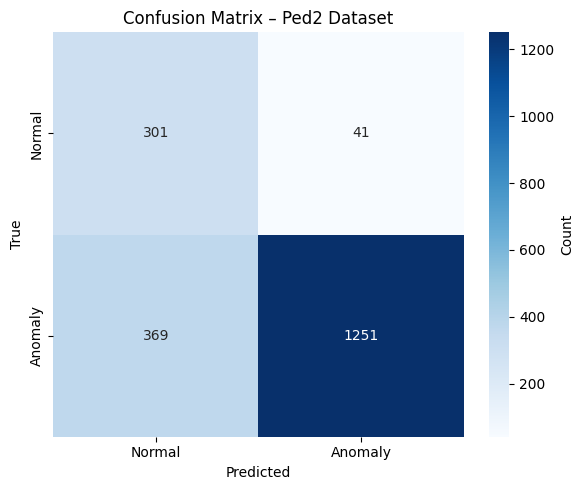


Dettagli:
True Negatives:  301
False Positives: 41
False Negatives: 369
True Positives:  1251


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE PED2 ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Ped2 Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

##5.2 MED

###Plot

Soglia globale ottimale (Youden) per MED: 0.3311
Numero totale di video trovati: 31


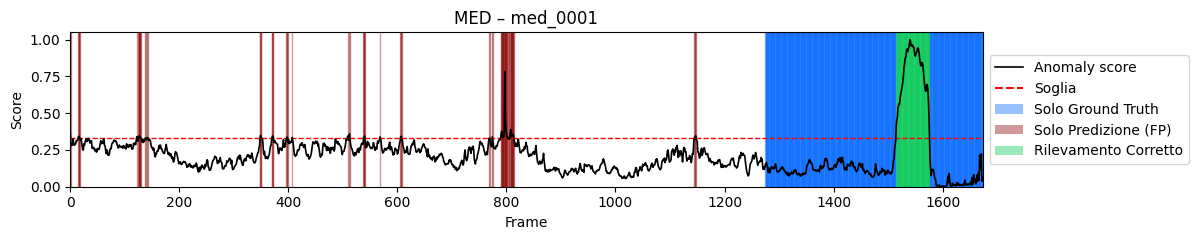

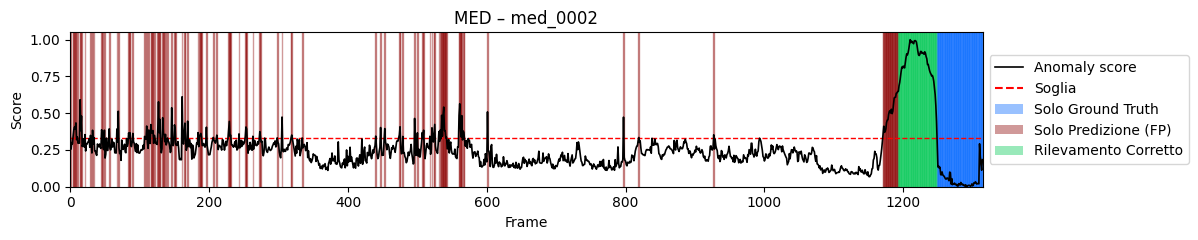

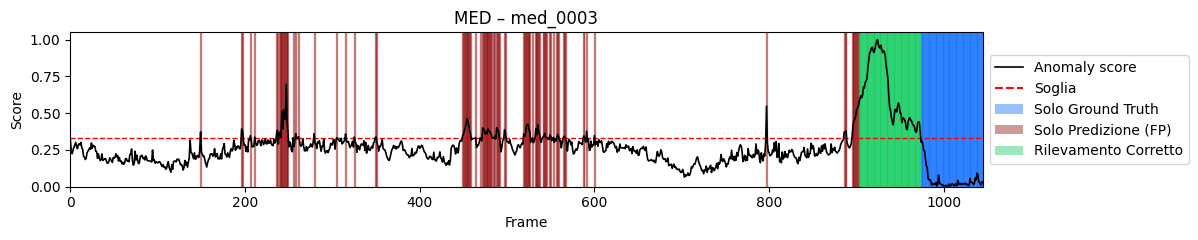

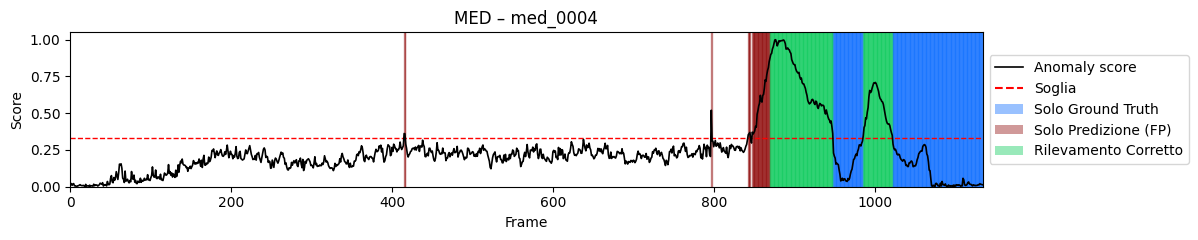

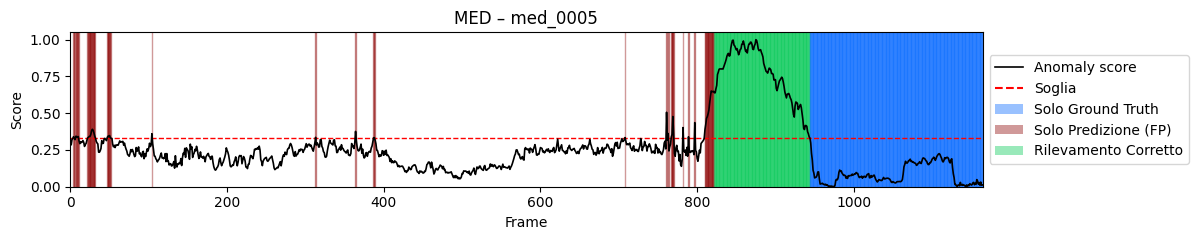

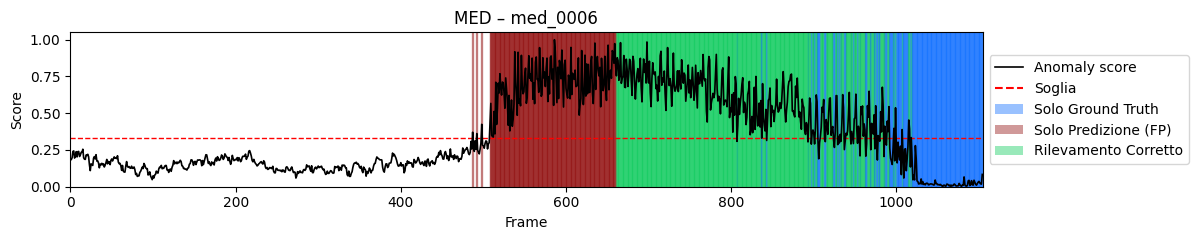

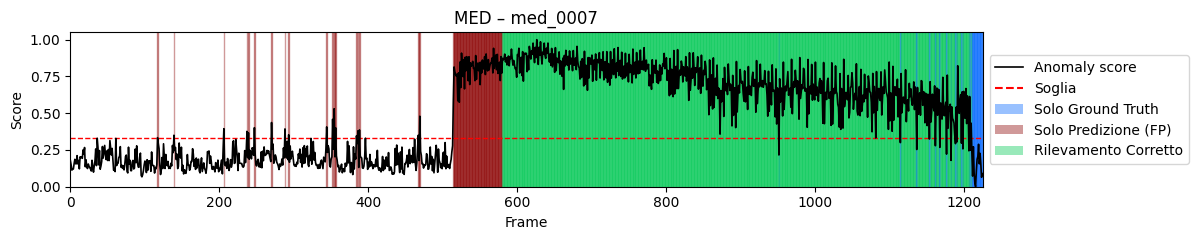

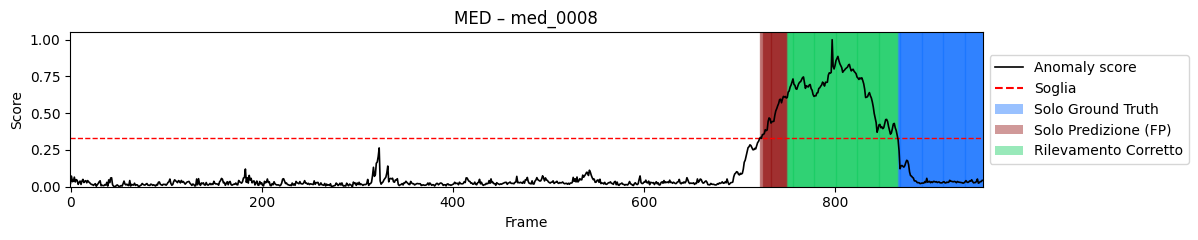

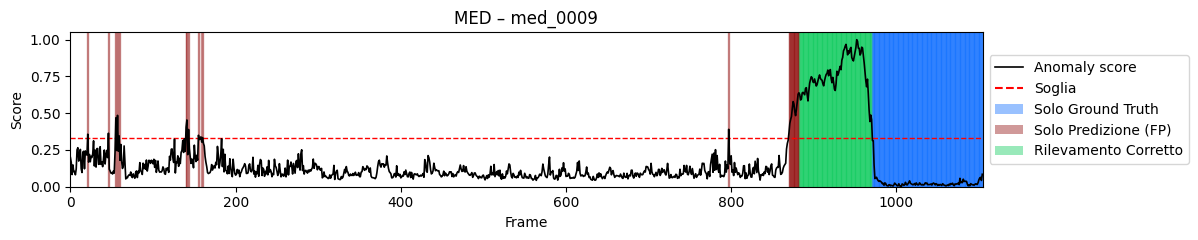

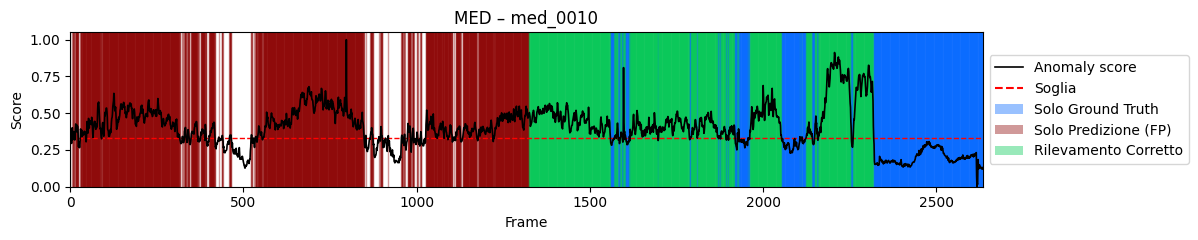

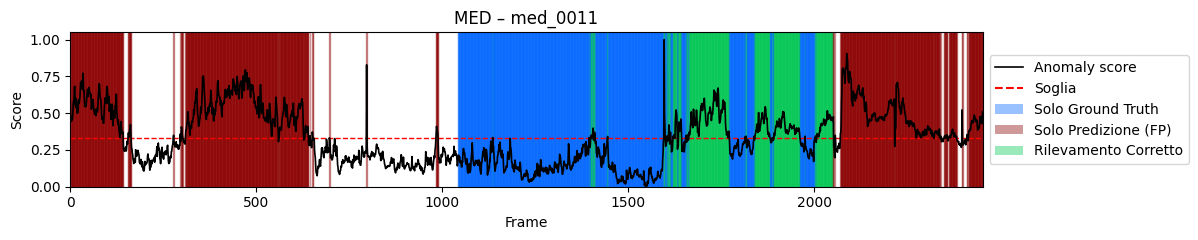

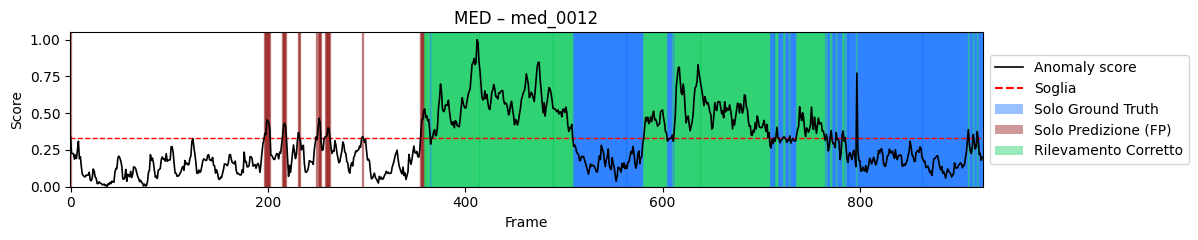

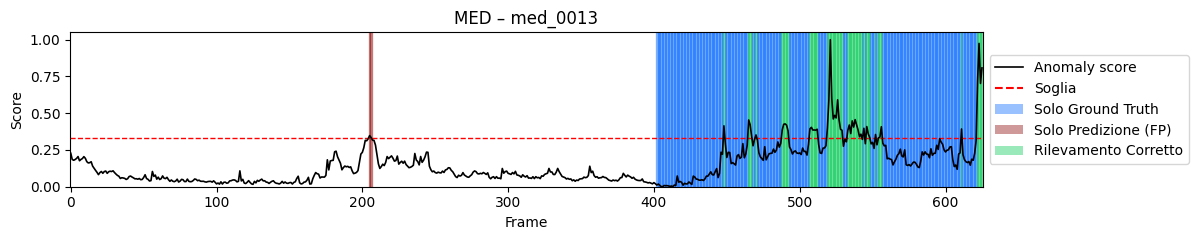

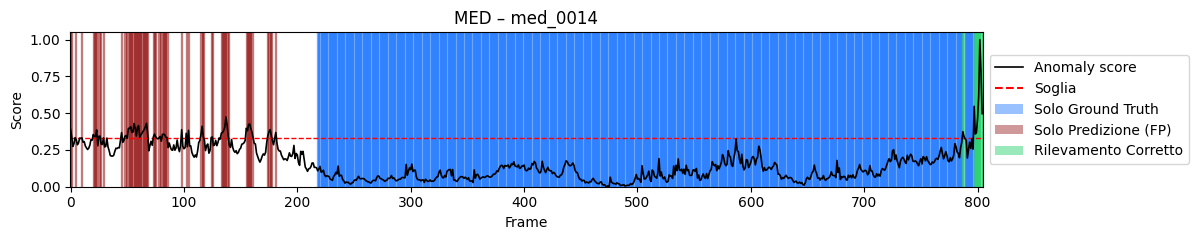

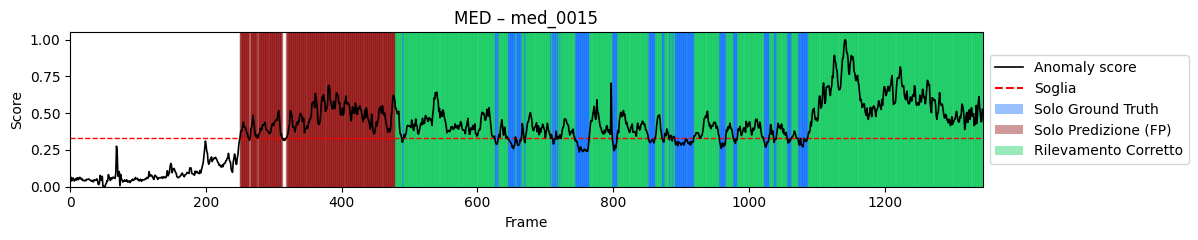

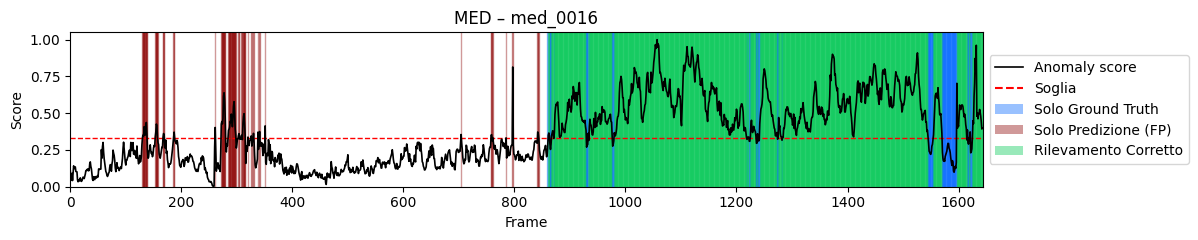

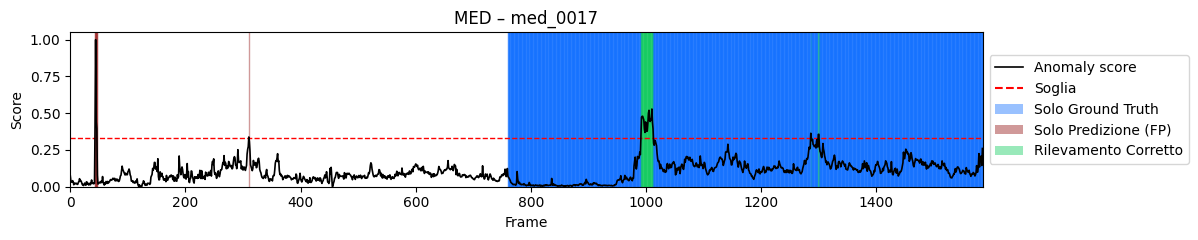

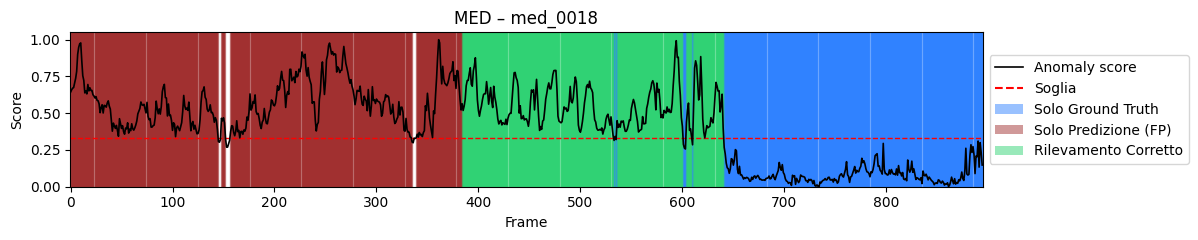

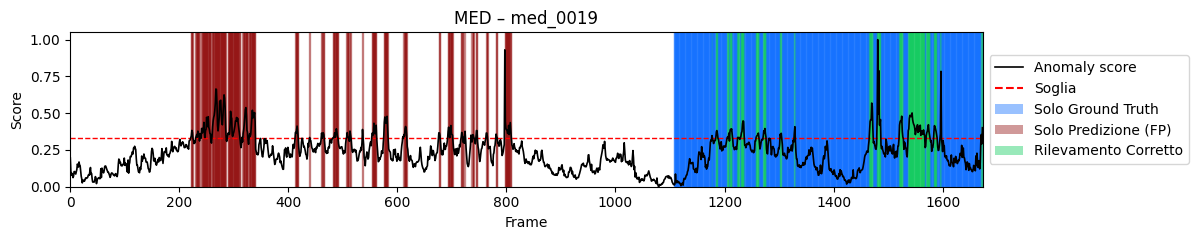

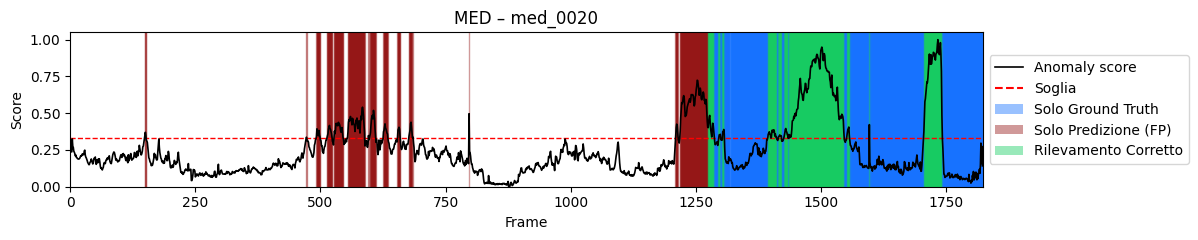

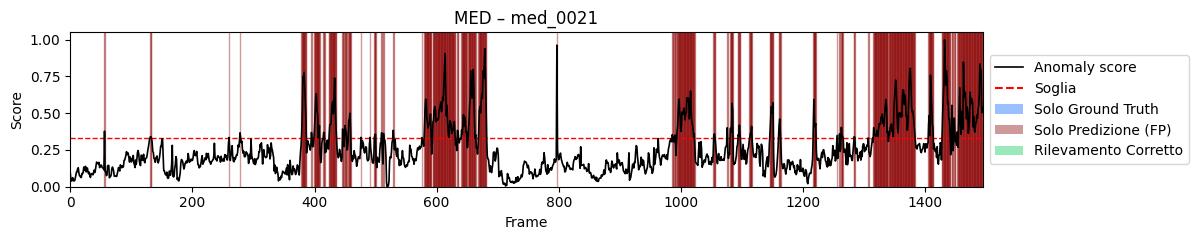

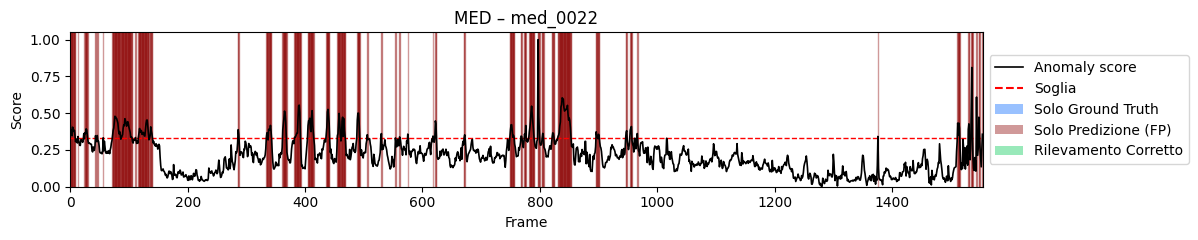

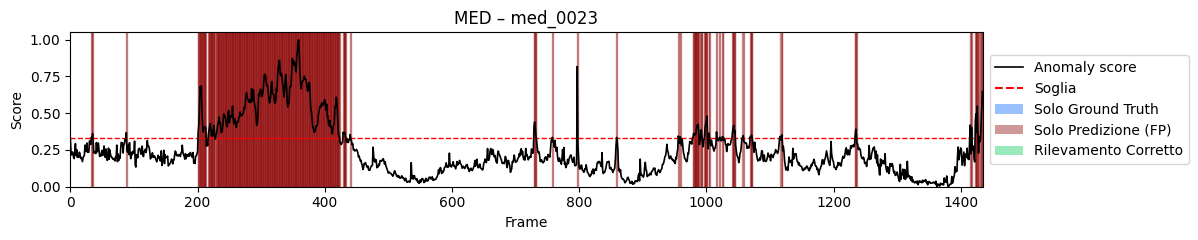

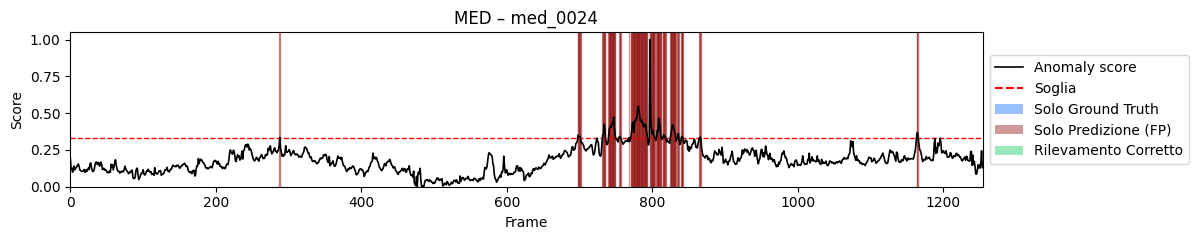

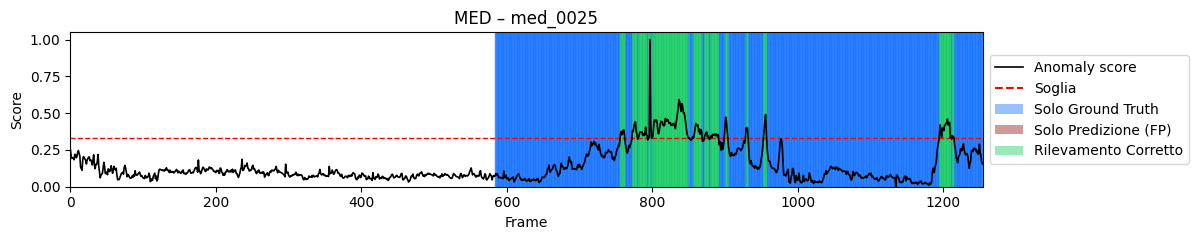

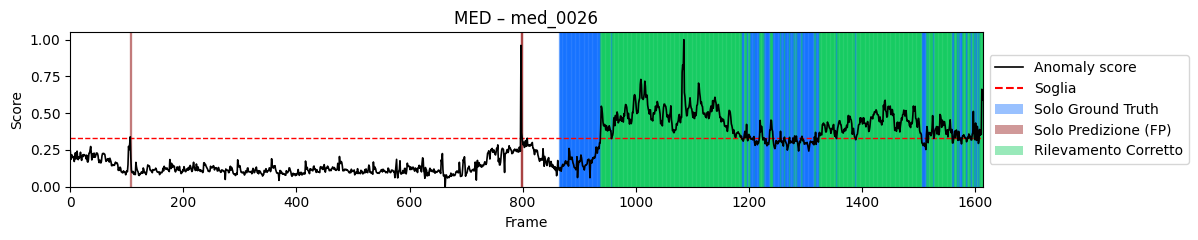

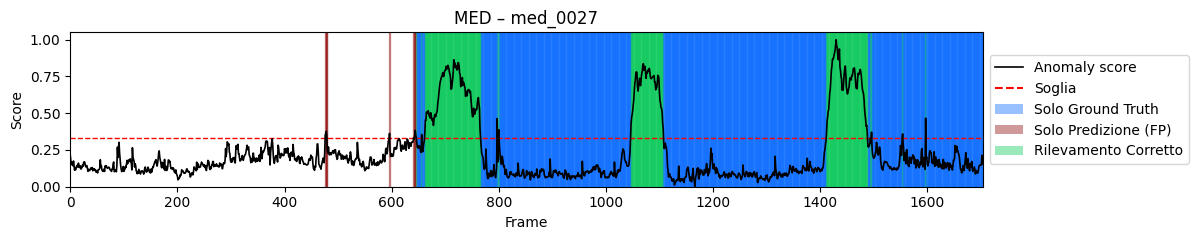

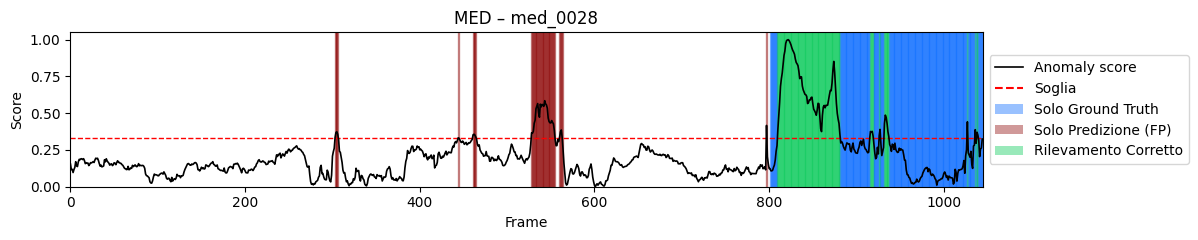

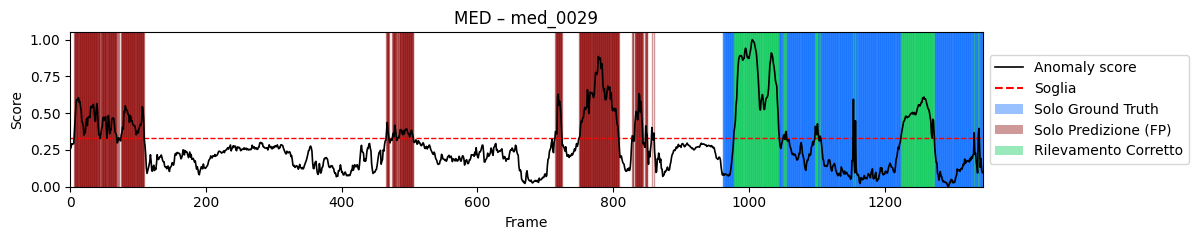

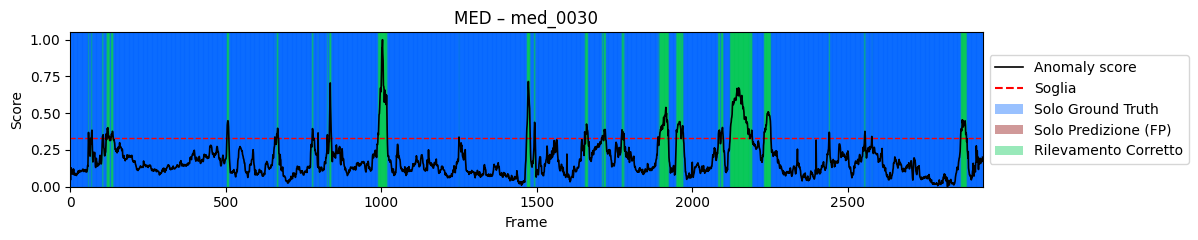

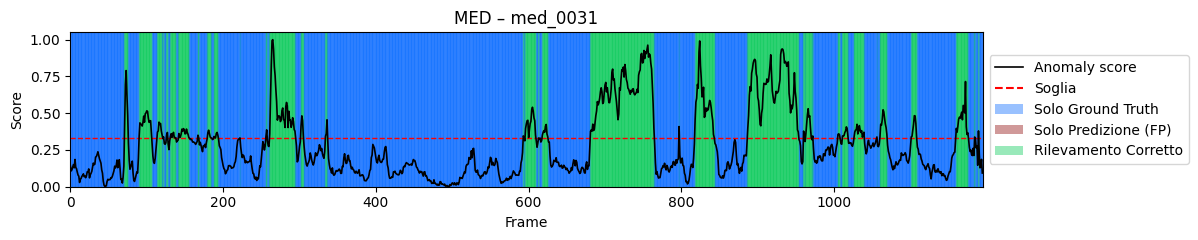

In [ ]:

OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/med/med_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/med/testing/frames")

# Caricamento dei dati dai file .npy generati dal test
try:
    psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)
except FileNotFoundError:
    psnr_list = np.load(OUT_DIR / "psnr.npy", allow_pickle=True)
    gt_list   = np.load(OUT_DIR / "gt.npy", allow_pickle=True)

# Recupero nomi delle cartelle video
video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames


# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    # Normalizzazione Min-Max invertita (PSNR basso = Score alto)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)
    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print(f"Soglia globale ottimale (Youden) per MED: {best_thr:.4f}")

#-------
# Plot
#-------
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    # Gestione nome video
    name = video_names[idx] if idx < len(video_names) else f"Video {idx+1}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.4, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        plt.Line2D([0], [0], color='red', linestyle='--', label='Soglia'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"MED – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Esecuzione finale
num_videos = len(psnr_list)
print(f"Numero totale di video trovati: {num_videos}")

for i in range(num_videos):
    plot_video_ped2(i)

###ROC CURVE

N video psnr: 31
N video gt: 31
AUC complessiva (MED): 57.3%


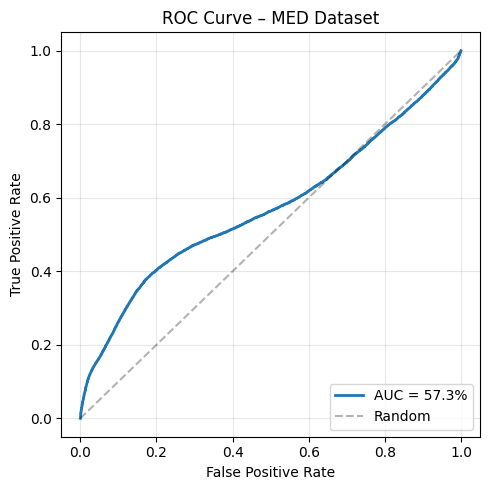

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (MED): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MED Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion matrix

Soglia ottimale (Youden): 0.3311

=== METRICHE MED ===
Accuracy:  64.32%
Precision: 59.02%
Recall:    39.07%
F1-Score:  47.01%

Matrice di Confusione:
[[21319  4832]
 [10856  6960]]


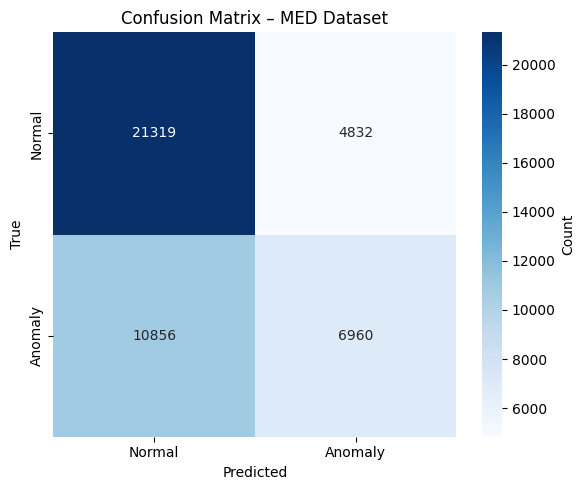


Dettagli:
True Negatives:  21319
False Positives: 4832
False Negatives: 10856
True Positives:  6960


In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/datasets/ASTNet_results/train_with_ped2_synth_2_random/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE MED ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – MED Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")